# Road Segmentation Experiment

Demonstrates the Part 1 U-Net road segmentation pipeline end-to-end:

1. Load a sample image
2. Load a trained model checkpoint
3. Run inference
4. Display the original image, probability mask, and binary road mask

This notebook does **not** duplicate any model/training code. It only calls
into the reusable modules under `ml/src/segmentation/`. If no trained
checkpoint exists yet, run training first from the repository root:

```bash
python -m ml.src.segmentation.generate_sample_data
python -m ml.src.segmentation.train
```

Ownership: Suryakant (AI/ML Lead) — image-level segmentation pipeline only.

In [1]:
# Ensure the notebook can import the `ml` package when run from ml/notebooks/.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "ml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repository root resolved to: {REPO_ROOT}")

Repository root resolved to: /home/claude/RouteResilience


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from ml.src.segmentation.config import CONFIG
from ml.src.segmentation.inference import predict_image
from ml.src.postprocessing.mask_cleanup import clean_mask

## 1. Load a sample image

Uses whichever synthetic/sample image is available under `ml/data/samples/images/`.
Replace `sample_image_path` with a real processed image path once available.

Using sample image: /home/claude/RouteResilience/ml/data/samples/images/synthetic_000.png


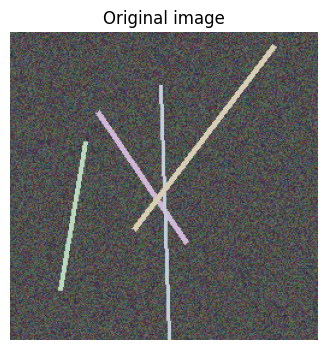

In [3]:
sample_images_dir = CONFIG.samples_dir / "images"
candidate_images = sorted(sample_images_dir.glob("*.png")) if sample_images_dir.exists() else []

if not candidate_images:
    raise FileNotFoundError(
        "No sample images found. Generate synthetic samples first:\n"
        "    python -m ml.src.segmentation.generate_sample_data"
    )

sample_image_path = candidate_images[0]
print(f"Using sample image: {sample_image_path}")

original_image = Image.open(sample_image_path)
plt.figure(figsize=(4, 4))
plt.imshow(original_image)
plt.title("Original image")
plt.axis("off")
plt.show()

## 2. Load the trained model + 3. Run inference

`predict_image` handles model loading, preprocessing, forward pass, and saving
outputs. It is the same function used by `python -m ml.src.segmentation.inference`.

In [4]:
model_path = CONFIG.model_path
if not model_path.exists():
    raise FileNotFoundError(
        f"No trained checkpoint found at {model_path}. Train first:\n"
        "    python -m ml.src.segmentation.train"
    )

output_dir = CONFIG.predictions_dir
result = predict_image(
    image_path=str(sample_image_path),
    model_path=str(model_path),
    output_dir=str(output_dir),
    threshold=CONFIG.threshold,
)
result

2026-09-13 05:42:26,426 | ml.src.segmentation.inference | INFO | Saved probability mask -> /home/claude/RouteResilience/outputs/predictions/synthetic_000_probability.png


2026-09-13 05:42:26,428 | ml.src.segmentation.inference | INFO | Saved binary mask -> /home/claude/RouteResilience/outputs/predictions/synthetic_000_mask.png


2026-09-13 05:42:26,429 | ml.src.segmentation.inference | INFO | Saved metadata -> /home/claude/RouteResilience/outputs/predictions/synthetic_000_metadata.json


{'probability': '/home/claude/RouteResilience/outputs/predictions/synthetic_000_probability.png',
 'binary': '/home/claude/RouteResilience/outputs/predictions/synthetic_000_mask.png',
 'metadata': '/home/claude/RouteResilience/outputs/predictions/synthetic_000_metadata.json'}

## 4. Display original image, probability mask, and binary road mask

Prediction metadata (downstream contract):
{
  "image_name": "synthetic_000.png",
  "width": 256,
  "height": 256,
  "threshold": 0.5,
  "model": "U-Net",
  "model_checkpoint": "/home/claude/RouteResilience/ml/models/unet_road_segmentation.pth",
  "task": "road_segmentation"
}


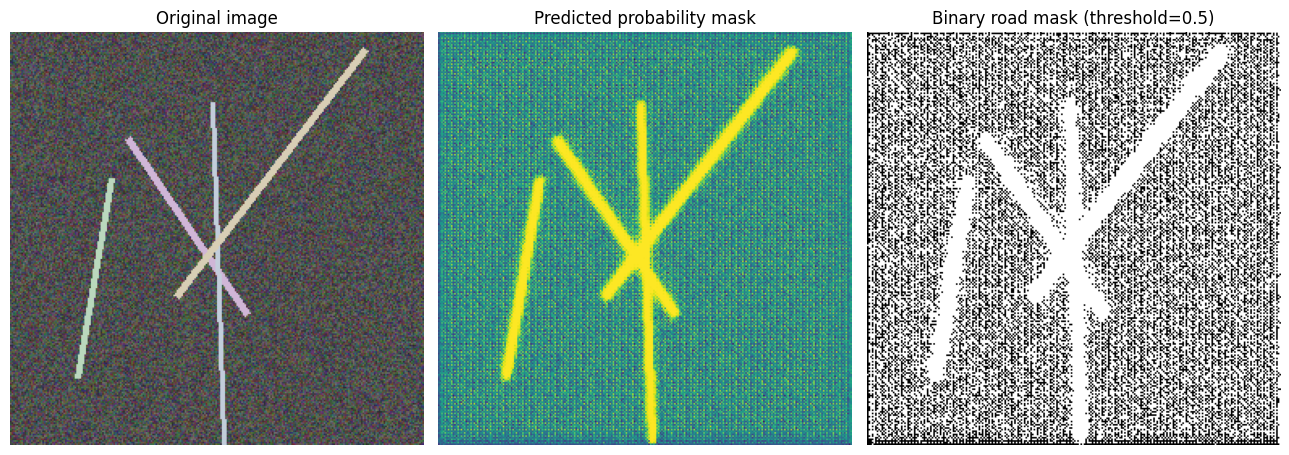

In [5]:
probability_mask = Image.open(result["probability"])
binary_mask = Image.open(result["binary"])

with open(result["metadata"]) as f:
    metadata = json.load(f)
print("Prediction metadata (downstream contract):")
print(json.dumps(metadata, indent=2))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(original_image)
axes[0].set_title("Original image")
axes[1].imshow(probability_mask, cmap="viridis")
axes[1].set_title("Predicted probability mask")
axes[2].imshow(binary_mask, cmap="gray")
axes[2].set_title(f"Binary road mask (threshold={metadata['threshold']})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Bonus: Part 1 mask cleanup foundation

Applies basic morphological cleanup (opening, closing, small-component removal)
to the raw binary mask. Full occlusion/gap *recovery* is out of scope for Part 1
and will be added in Part 2.

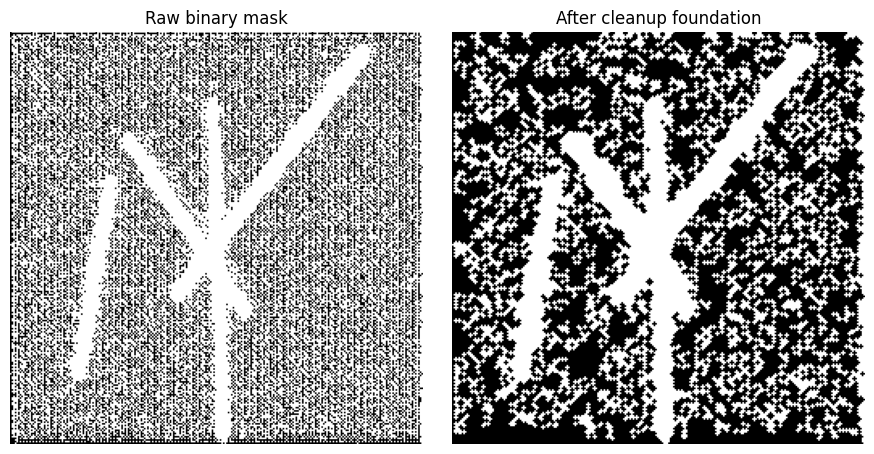

In [6]:
binary_array = np.array(binary_mask).astype(np.float32) / 255.0
cleaned = clean_mask(binary_array, threshold=0.5)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(binary_mask, cmap="gray")
axes[0].set_title("Raw binary mask")
axes[1].imshow(cleaned, cmap="gray")
axes[1].set_title("After cleanup foundation")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()